In [4]:
import torch

In [5]:
import requests
import os
import fastf1
from fastf1 import plotting
from fastf1.ergast import Ergast
from datetime import datetime, timedelta
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [6]:
import requests
import pandas as pd
import time

def extract_results_to_csv(start_year, end_year):
    all_results = []
    base_url = "http://api.jolpi.ca/ergast/f1/{year}.json"
    results_url_template = "http://api.jolpi.ca/ergast/f1/{year}/{round}/results.json"

    for year in range(start_year, end_year + 1):
        print(f"\n--- Processing Season: {year} ---")
        
        try:
            # Get the schedule for the year
            schedule_url = base_url.format(year=year)
            schedule_response = requests.get(schedule_url)
            schedule_response.raise_for_status()
            schedule = schedule_response.json()['MRData']['RaceTable']['Races']
            print(f"Successfully fetched schedule for {year}.")

            for race in schedule:
                round_num = race['round']
                race_name = race['raceName']
                race_date = race['date']
                circuit_name = race['Circuit']['circuitName']
                
                print(f"  Processing {race_name} (Round {round_num})...")
                
                # Fetch results for each race
                results_url = results_url_template.format(year=year, round=round_num)
                results_response = requests.get(results_url)
                results_response.raise_for_status()

                results_data = results_response.json()
                if results_data['MRData']['RaceTable']['Races']:
                    results = results_data['MRData']['RaceTable']['Races'][0]['Results']
                    
                    for res in results:
                        all_results.append({
                            'season_year': year,
                            'race_round_number': int(round_num),
                            'race_name': race_name,
                            'race_date': race_date,
                            'circuit_name': circuit_name,
                            'driver_name': f"{res['Driver']['givenName']} {res['Driver']['familyName']}",
                            'driver_nationality': res['Driver']['nationality'],
                            'constructor_name': res['Constructor']['name'],
                            'grid_position': int(res['grid']) if int(res['grid']) > 0 else 20,
                            'final_position': int(res['position']),
                            'points': float(res.get('points', 0)),
                            'laps_completed': int(res.get('laps', 0)),
                            'race_time': res.get('Time', {}).get('time', 'N/A'),
                            'fastest_lap': res.get('FastestLap', {}).get('Time', {}).get('time', 'N/A'),
                            'status': res['status']
                        })
                
                print(f"    ✓ Processed {race_name}")
                time.sleep(0.3)  # Small delay to be respectful

        except requests.exceptions.RequestException as e:
            print(f"✗ Error processing year {year}: {e}")
            continue

    if all_results:
        df = pd.DataFrame(all_results)
        df.to_csv('f1_results_2017_2025.csv', index=False)
        print(f"\n✅ Data extraction complete! Saved {len(all_results)} records to 'f1_results_2022_2025.csv'")
        print(f"Columns included: {list(df.columns)}")
    else:
        print("\n❌ No data was extracted. Please check the error messages.")

extract_results_to_csv(2017, 2025)



--- Processing Season: 2017 ---
Successfully fetched schedule for 2017.
  Processing Australian Grand Prix (Round 1)...
    ✓ Processed Australian Grand Prix
  Processing Chinese Grand Prix (Round 2)...
    ✓ Processed Chinese Grand Prix
  Processing Bahrain Grand Prix (Round 3)...
    ✓ Processed Bahrain Grand Prix
  Processing Russian Grand Prix (Round 4)...
    ✓ Processed Russian Grand Prix
  Processing Spanish Grand Prix (Round 5)...
    ✓ Processed Spanish Grand Prix
  Processing Monaco Grand Prix (Round 6)...
    ✓ Processed Monaco Grand Prix
  Processing Canadian Grand Prix (Round 7)...
    ✓ Processed Canadian Grand Prix
  Processing Azerbaijan Grand Prix (Round 8)...
    ✓ Processed Azerbaijan Grand Prix
  Processing Austrian Grand Prix (Round 9)...
    ✓ Processed Austrian Grand Prix
  Processing British Grand Prix (Round 10)...
    ✓ Processed British Grand Prix
  Processing Hungarian Grand Prix (Round 11)...
    ✓ Processed Hungarian Grand Prix
  Processing Belgian Grand 

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [8]:
df = pd.read_csv('f1_results_2017_2025.csv')


In [9]:
df.head()

,season_year,race_round_number,race_name,race_date,circuit_name,driver_name,driver_nationality,constructor_name,grid_position,final_position,points,laps_completed,race_time,fastest_lap,status
0,2017,1,Australian Grand Prix,2017-03-26,Albert Park Grand Prix Circuit,Sebastian Vettel,German,Ferrari,2,1,25.0,57,1:24:11.672,1:26.638,Finished
1,2017,1,Australian Grand Prix,2017-03-26,Albert Park Grand Prix Circuit,Lewis Hamilton,British,Mercedes,1,2,18.0,57,+9.975,1:27.033,Finished
2,2017,1,Australian Grand Prix,2017-03-26,Albert Park Grand Prix Circuit,Valtteri Bottas,Finnish,Mercedes,3,3,15.0,57,+11.250,1:26.593,Finished
3,2017,1,Australian Grand Prix,2017-03-26,Albert Park Grand Prix Circuit,Kimi Räikkönen,Finnish,Ferrari,4,4,12.0,57,+22.393,1:26.538,Finished
4,2017,1,Australian Grand Prix,2017-03-26,Albert Park Grand Prix Circuit,Max Verstappen,Dutch,Red Bull,5,5,10.0,57,+28.827,1:26.964,Finished


In [10]:
df.describe()

,season_year,race_round_number,grid_position,final_position,points,laps_completed
count,3638.000000,3638.000000,3638.000000,3638.000000,3638.000000,3638.000000
mean,2020.932106,10.854316,10.523364,10.494777,5.069956,54.033260
std,2.505876,6.180201,5.786779,5.764353,7.213351,17.734725
min,2017.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,2019.000000,6.000000,6.000000,5.250000,0.000000,51.000000
50%,2021.000000,11.000000,11.000000,10.000000,0.750000,56.000000
75%,2023.000000,16.000000,16.000000,15.000000,9.000000,66.000000
max,2025.000000,24.000000,20.000000,20.000000,26.000000,87.000000


In [11]:
df.isnull().sum()

season_year              0
race_round_number        0
race_name                0
race_date                0
circuit_name             0
driver_name              0
driver_nationality       0
constructor_name         0
grid_position            0
final_position           0
points                   0
laps_completed           0
race_time             1355
fastest_lap            157
status                   0
dtype: int64

In [12]:
df.columns

Index(['season_year', 'race_round_number', 'race_name', 'race_date',
       'circuit_name', 'driver_name', 'driver_nationality', 'constructor_name',
       'grid_position', 'final_position', 'points', 'laps_completed',
       'race_time', 'fastest_lap', 'status'],
      dtype='object')

In [13]:
df.shape

(3638, 15)

In [14]:
df['season_year'].nunique()

9

In [15]:

print("The number of unique drivers is:", df['driver_name'].nunique())
print("The number of unique constructors is:", df['constructor_name'].nunique())
print("The number of unique circuits is:", df['circuit_name'].nunique())


The number of unique drivers is: 48
The number of unique constructors is: 16
The number of unique circuits is: 32


In [16]:
print("Races per season:")
df.groupby('season_year')['race_round_number'].nunique()

Races per season:


season_year
2017    20
2018    21
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24
2025    13
Name: race_round_number, dtype: int64

## Winner Analysis

In [17]:
# Most successful drivers (race wins)
race_winners = df[df['final_position'] == 1]['driver_name'].value_counts()
race_winners

driver_name
Max Verstappen      64
Lewis Hamilton      52
Sebastian Vettel    11
Valtteri Bottas     10
Oscar Piastri        8
Charles Leclerc      8
Lando Norris         8
Sergio Pérez         6
George Russell       4
Daniel Ricciardo     4
Carlos Sainz         4
Kimi Räikkönen       1
Esteban Ocon         1
Pierre Gasly         1
Name: count, dtype: int64

In [18]:
constructor_wins = df[df['final_position'] == 1]['constructor_name'].value_counts()
print(f"\nTop Constructor Wins:")
print(constructor_wins.head(8))


Top Constructor Wins:
constructor_name
Red Bull          72
Mercedes          66
Ferrari           24
McLaren           17
AlphaTauri         1
Racing Point       1
Alpine F1 Team     1
Name: count, dtype: int64


## Most Successful Qualifying

In [19]:
print("Wins from each grid position:")
df[df['final_position'] == 1]['grid_position'].value_counts().sort_index()

Wins from each grid position:


grid_position
1     93
2     43
3     21
4      7
5      3
6      5
7      1
8      1
9      1
10     4
14     2
17     1
Name: count, dtype: int64

In [20]:
print("Pole Position Results:")
df[df['grid_position'] == 1]['final_position'].value_counts().sort_index()

Pole Position Results:


final_position
1     93
2     35
3     18
4     10
5      3
6      1
7      2
8      2
9      2
15     1
17     1
18     3
19     6
20     5
Name: count, dtype: int64

In [21]:
print(f"\nAverage finish position by starting grid:")
df.groupby('grid_position')['final_position'].mean()


Average finish position by starting grid:


grid_position
1      3.439560
2      4.071823
3      5.054945
4      6.076923
5      7.593407
6      7.857143
7      8.861878
8      9.988950
9      9.989011
10    11.348066
11    11.386740
12    12.192308
13    12.672222
14    13.364641
15    13.505556
16    13.928177
17    14.439560
18    14.748603
19    14.611111
20    14.617347
Name: final_position, dtype: float64

In [22]:
df['status'].value_counts()

status
Finished            2025
+1 Lap               654
Lapped               253
Retired              123
+2 Laps              122
Collision             89
Accident              49
Engine                47
Collision damage      37
Brakes                26
Power Unit            25
Gearbox               20
Disqualified          14
Hydraulics            13
+3 Laps               13
Suspension            12
Wheel                  9
Power loss             8
Did not start          8
Puncture               6
Withdrew               5
Oil leak               5
Water pressure         5
Fuel pressure          5
Electrical             5
Exhaust                4
Overheating            4
Spun off               4
Mechanical             3
Electronics            3
Battery                3
Water leak             3
Undertray              3
Turbo                  3
Front wing             2
Wheel nut              2
Driveshaft             2
Vibrations             2
Illness                2
Transmission      

## Fastest Lap of Each  CIRCUIT

In [23]:
def get_fastest_laps_by_circuit(csv_file):
    """
    Extract the fastest lap time for each circuit from F1 race data
    """
    # Load data
    df1 = pd.read_csv(csv_file)
    
    # Convert lap times to seconds for proper comparison
    def parse_laptime(time_str):
        if pd.isna(time_str) or time_str == 'N/A':
            return np.nan
        try:
            if ':' in str(time_str):
                min_sec = str(time_str).split(':')
                return int(min_sec[0]) * 60 + float(min_sec[1])
            return float(time_str)
        except:
            return np.nan
    
    df1['lap_seconds'] = df1['fastest_lap'].apply(parse_laptime)
    df_valid = df1.dropna(subset=['lap_seconds'])
    
    # Get fastest lap per circuit
    fastest_by_circuit = df_valid.loc[df_valid.groupby('circuit_name')['lap_seconds'].idxmin()]
    
    # Create results
    results = fastest_by_circuit.sort_values('circuit_name')[
        ['circuit_name', 'fastest_lap', 'driver_name', 'constructor_name', 'season_year', 'race_name']
    ].copy()
    
    return results

# Execute the function
fastest_laps = get_fastest_laps_by_circuit('f1_results_2019_2025.csv')

# Display results
print("🏎️  FASTEST LAP RECORDS BY CIRCUIT (2019-2025)")
print("=" * 70)

for _, record in fastest_laps.iterrows():
    print(f"🏁 {record['circuit_name']}")
    print(f"   ⏱️  {record['fastest_lap']}")
    print(f"   🏆 {record['driver_name']} ({record['constructor_name']})")
    print(f"   📅 {record['season_year']} {record['race_name']}")
    print()


🏎️  FASTEST LAP RECORDS BY CIRCUIT (2019-2025)
🏁 Albert Park Grand Prix Circuit
   ⏱️  1:19.813
   🏆 Charles Leclerc (Ferrari)
   📅 2024 Australian Grand Prix

🏁 Autodromo Enzo e Dino Ferrari
   ⏱️  1:15.484
   🏆 Lewis Hamilton (Mercedes)
   📅 2020 Emilia Romagna Grand Prix

🏁 Autodromo Internazionale del Mugello
   ⏱️  1:18.833
   🏆 Lewis Hamilton (Mercedes)
   📅 2020 Tuscan Grand Prix

🏁 Autodromo Nazionale di Monza
   ⏱️  1:21.432
   🏆 Lando Norris (McLaren)
   📅 2024 Italian Grand Prix

🏁 Autódromo Hermanos Rodríguez
   ⏱️  1:17.774
   🏆 Valtteri Bottas (Mercedes)
   📅 2021 Mexico City Grand Prix

🏁 Autódromo Internacional do Algarve
   ⏱️  1:18.750
   🏆 Lewis Hamilton (Mercedes)
   📅 2020 Portuguese Grand Prix

🏁 Autódromo José Carlos Pace
   ⏱️  1:10.698
   🏆 Valtteri Bottas (Mercedes)
   📅 2019 Brazilian Grand Prix

🏁 Bahrain International Circuit
   ⏱️  55.404
   🏆 George Russell (Mercedes)
   📅 2020 Sakhir Grand Prix

🏁 Baku City Circuit
   ⏱️  1:43.009
   🏆 Charles Leclerc (F

In [24]:
df.head()

,season_year,race_round_number,race_name,race_date,circuit_name,driver_name,driver_nationality,constructor_name,grid_position,final_position,points,laps_completed,race_time,fastest_lap,status
0,2017,1,Australian Grand Prix,2017-03-26,Albert Park Grand Prix Circuit,Sebastian Vettel,German,Ferrari,2,1,25.0,57,1:24:11.672,1:26.638,Finished
1,2017,1,Australian Grand Prix,2017-03-26,Albert Park Grand Prix Circuit,Lewis Hamilton,British,Mercedes,1,2,18.0,57,+9.975,1:27.033,Finished
2,2017,1,Australian Grand Prix,2017-03-26,Albert Park Grand Prix Circuit,Valtteri Bottas,Finnish,Mercedes,3,3,15.0,57,+11.250,1:26.593,Finished
3,2017,1,Australian Grand Prix,2017-03-26,Albert Park Grand Prix Circuit,Kimi Räikkönen,Finnish,Ferrari,4,4,12.0,57,+22.393,1:26.538,Finished
4,2017,1,Australian Grand Prix,2017-03-26,Albert Park Grand Prix Circuit,Max Verstappen,Dutch,Red Bull,5,5,10.0,57,+28.827,1:26.964,Finished


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3638 entries, 0 to 3637
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   season_year         3638 non-null   int64  
 1   race_round_number   3638 non-null   int64  
 2   race_name           3638 non-null   object 
 3   race_date           3638 non-null   object 
 4   circuit_name        3638 non-null   object 
 5   driver_name         3638 non-null   object 
 6   driver_nationality  3638 non-null   object 
 7   constructor_name    3638 non-null   object 
 8   grid_position       3638 non-null   int64  
 9   final_position      3638 non-null   int64  
 10  points              3638 non-null   float64
 11  laps_completed      3638 non-null   int64  
 12  race_time           2283 non-null   object 
 13  fastest_lap         3481 non-null   object 
 14  status              3638 non-null   object 
dtypes: float64(1), int64(5), object(9)
memory usage: 426.5+

## Visualisation

In [26]:
race_winners

driver_name
Max Verstappen      64
Lewis Hamilton      52
Sebastian Vettel    11
Valtteri Bottas     10
Oscar Piastri        8
Charles Leclerc      8
Lando Norris         8
Sergio Pérez         6
George Russell       4
Daniel Ricciardo     4
Carlos Sainz         4
Kimi Räikkönen       1
Esteban Ocon         1
Pierre Gasly         1
Name: count, dtype: int64

In [27]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

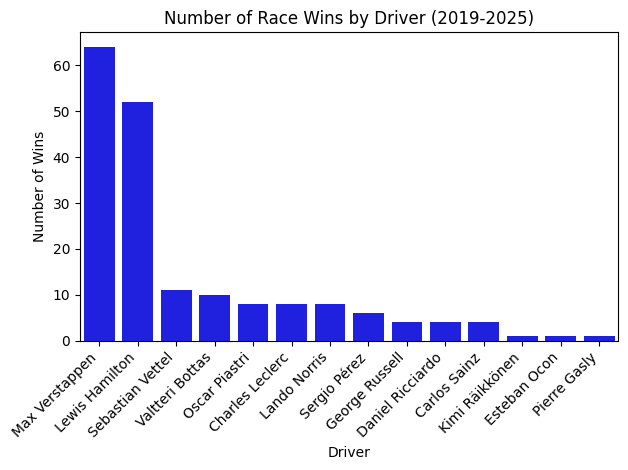

In [28]:
sns.barplot(x=race_winners.index, y=race_winners.values, color='b')
plt.xticks(rotation=45, ha='right')
plt.title('Number of Race Wins by Driver (2019-2025)')
plt.xlabel('Driver')
plt.ylabel('Number of Wins')
plt.tight_layout()

In [29]:
constructor_wins

constructor_name
Red Bull          72
Mercedes          66
Ferrari           24
McLaren           17
AlphaTauri         1
Racing Point       1
Alpine F1 Team     1
Name: count, dtype: int64

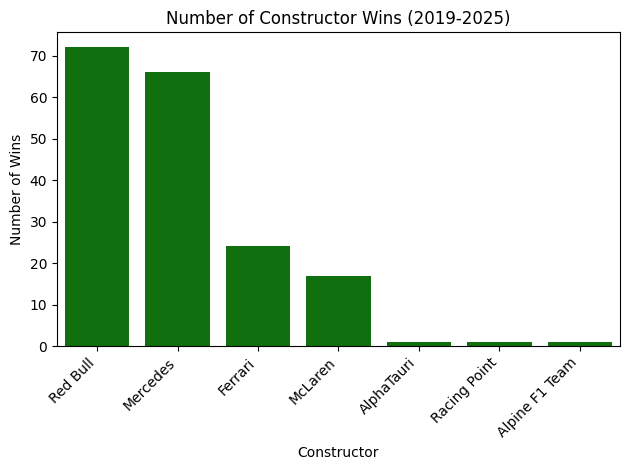

In [30]:
sns.barplot(x=constructor_wins.index, y=constructor_wins.values, color='g')
plt.xticks(rotation=45, ha='right')
plt.title('Number of Constructor Wins (2019-2025)')
plt.xlabel('Constructor')
plt.ylabel('Number of Wins')
plt.tight_layout()

In [31]:
podium_finishers = df[df['final_position'] <= 3]['driver_name'].value_counts()
podium_finishers

driver_name
Max Verstappen           110
Lewis Hamilton            98
Valtteri Bottas           58
Charles Leclerc           48
Lando Norris              37
Sebastian Vettel          36
Sergio Pérez              32
Carlos Sainz              27
Oscar Piastri             21
George Russell            20
Kimi Räikkönen            19
Daniel Ricciardo          14
Fernando Alonso            9
Pierre Gasly               5
Esteban Ocon               4
Lance Stroll               3
Alexander Albon            2
Daniil Kvyat               1
Andrea Kimi Antonelli      1
Nico Hülkenberg            1
Name: count, dtype: int64

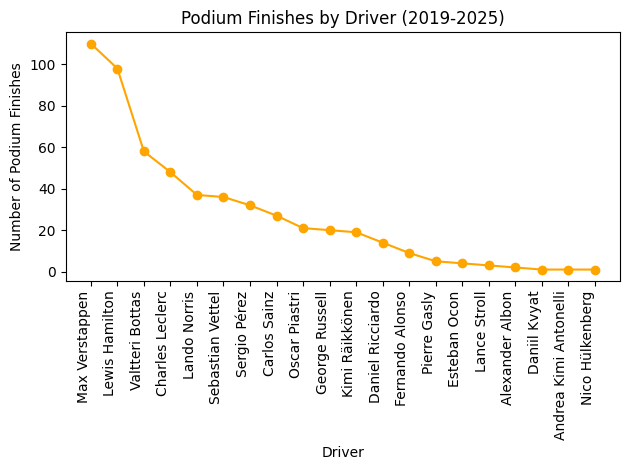

In [32]:
plt.plot(podium_finishers.index, podium_finishers.values, marker='o', linestyle='-', color='orange')
plt.xticks(rotation=90, ha='right')
plt.xlabel('Driver')
plt.ylabel('Number of Podium Finishes')
plt.title('Podium Finishes by Driver (2019-2025)')
plt.tight_layout()

<Figure size 1200x600 with 0 Axes>

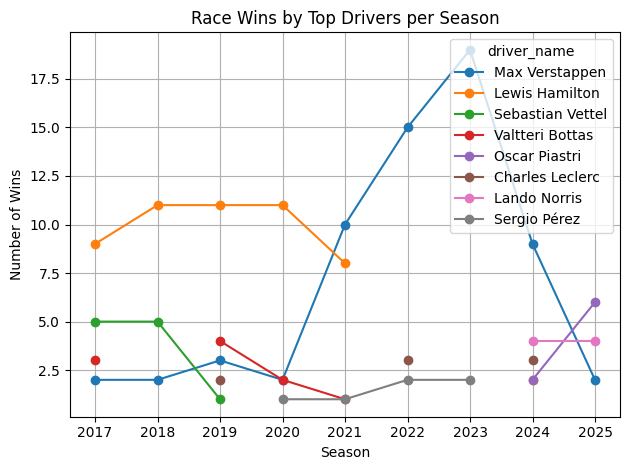

In [33]:
plt.figure(figsize=(12, 6))
top_drivers = race_winners.nlargest(8).index
season_wins = df[df['final_position'] == 1].groupby(['season_year', 'driver_name']).size().unstack()
season_wins[top_drivers].plot(marker='o')
plt.title('Race Wins by Top Drivers per Season')
plt.xlabel('Season')
plt.ylabel('Number of Wins')
plt.grid(True)
plt.tight_layout()
plt.show()

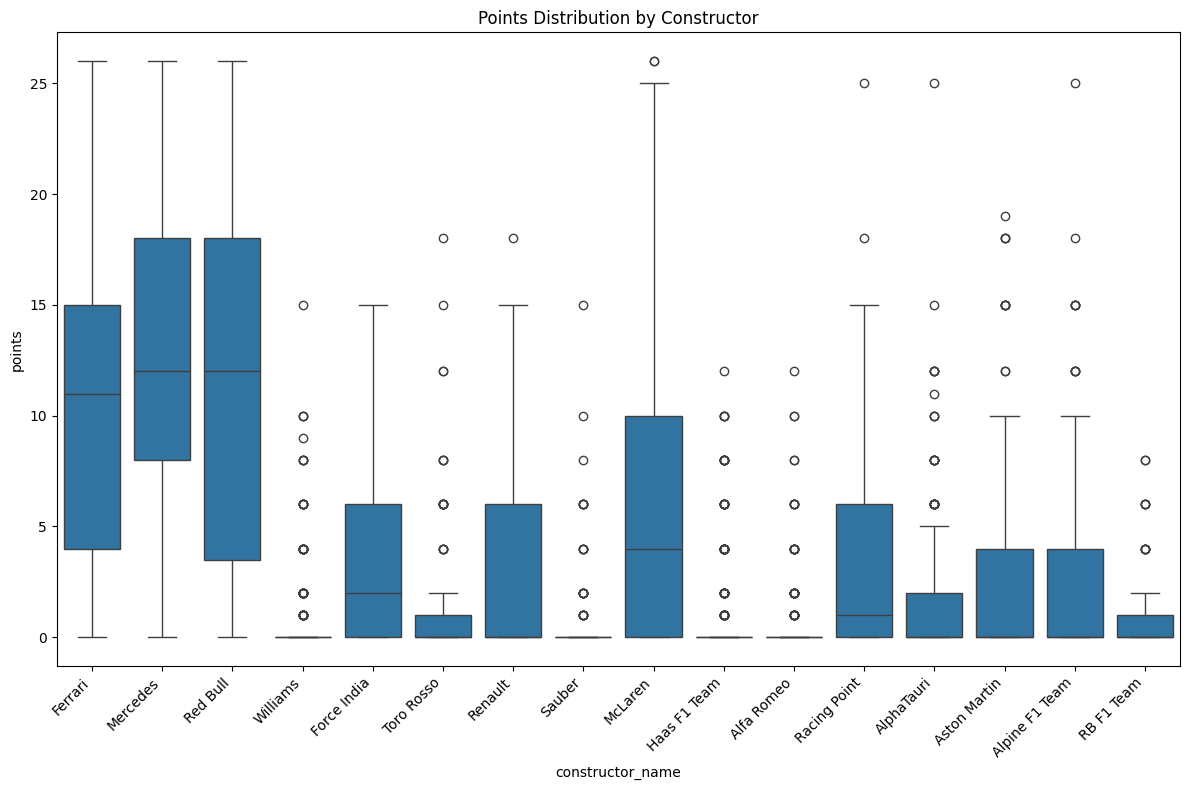

In [34]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='constructor_name', y='points', data=df)
plt.title('Points Distribution by Constructor')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
winners_df = df[df['final_position'] == 1]
wins_per_circuit_driver = winners_df.groupby(['circuit_name', 'driver_name']).size().reset_index(name='win_count')




In [36]:

most_wins_by_driver_on_circuit = wins_per_circuit_driver.sort_values('win_count', ascending=False)\
    .groupby('circuit_name').first().reset_index()

# Show top 10 for preview
most_wins_by_driver_on_circuit.head()

,circuit_name,driver_name,win_count
0,Albert Park Grand Prix Circuit,Sebastian Vettel,2
1,Autodromo Enzo e Dino Ferrari,Max Verstappen,4
2,Autodromo Internazionale del Mugello,Lewis Hamilton,1
3,Autodromo Nazionale di Monza,Lewis Hamilton,2
4,Autódromo Hermanos Rodríguez,Max Verstappen,5


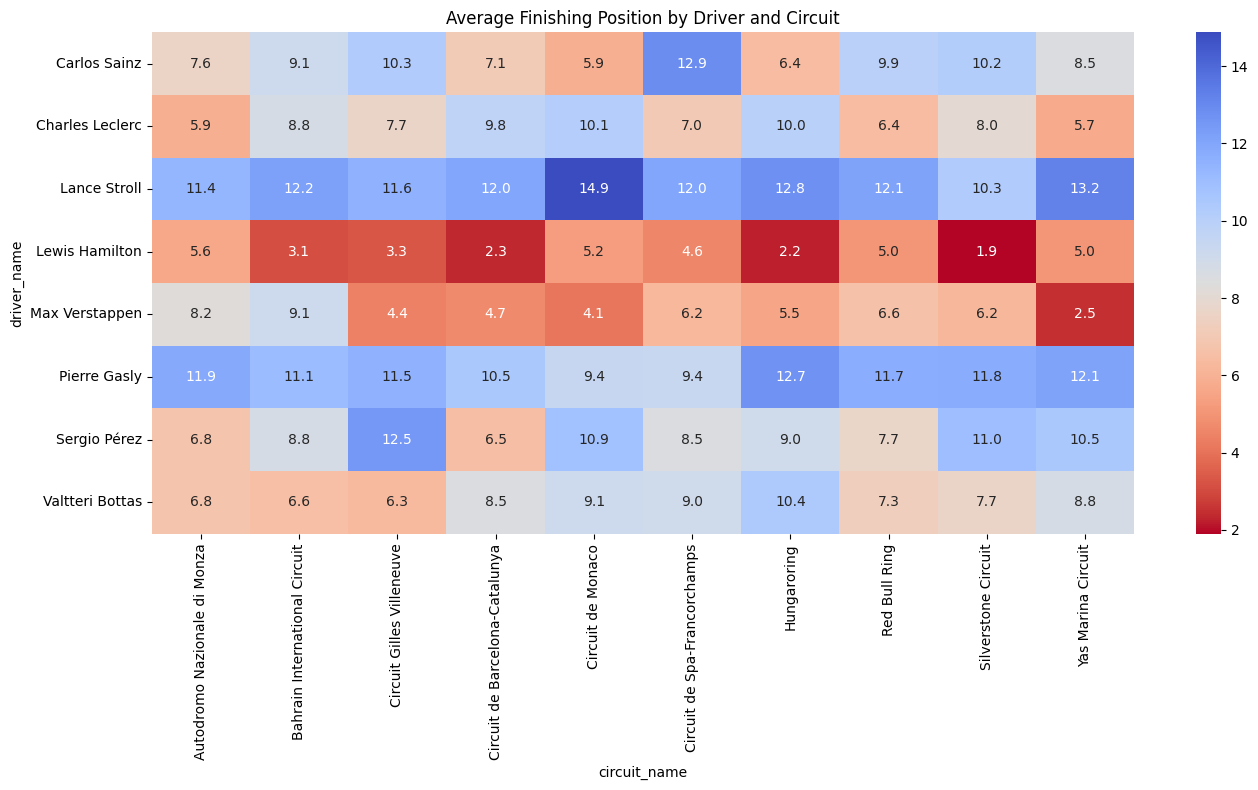

In [37]:
top_circuits = df['circuit_name'].value_counts().nlargest(10).index
top_drivers = df['driver_name'].value_counts().nlargest(8).index

circuit_perf = pd.pivot_table(
    df[df['circuit_name'].isin(top_circuits) & df['driver_name'].isin(top_drivers)],
    values='final_position',
    index='driver_name',
    columns='circuit_name',
    aggfunc='mean'
)

plt.figure(figsize=(14, 8))
sns.heatmap(circuit_perf, annot=True, cmap='coolwarm_r', fmt='.1f')
plt.title('Average Finishing Position by Driver and Circuit')
plt.tight_layout()
plt.show()

In [38]:
dnf_status = df[df['status'] !='Finished']['status'].value_counts().nlargest(10)
dnf_status

status
+1 Lap              654
Lapped              253
Retired             123
+2 Laps             122
Collision            89
Accident             49
Engine               47
Collision damage     37
Brakes               26
Power Unit           25
Name: count, dtype: int64